# OceanoIA — Módulo 2 (RNN/LSTM)
## 01 · Análisis Exploratorio de Datos (EDA)

Dataset: `data/processed/oceano_merged.csv` — series temporales diarias de la costa del Pacífico de Costa Rica.

 oleaje, marea, SST, viento, presión y fase lunar.

## 0. Importar librerías y cargar los datos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)
# Ruta al CSV unificado (el notebook está en /notebooks, el dato en /data/processed)
RUTA = os.path.join('..', 'data', 'processed', 'oceano_merged.csv')

df = pd.read_csv(RUTA, parse_dates=['Fecha'], index_col='Fecha')
df = df.sort_index()
print('Filas:', df.shape[0], '| Columnas:', df.shape[1])
df.head()

Filas: 517 | Columnas: 12


,Oleaje_m,Periodo_Oleaje_s,Direccion_Oleaje_deg,Marea_m,SST_Copernicus,temp_aire_c,temp_min_c,temp_max_c,humedad_pct,viento_kmh,presion_hpa,nubosidad_octas
Fecha,,,,,,,,,,,,
2025-01-01,0.376667,8.060417,190.000000,0.334583,27.862621,22.6,20.4,26.1,72.0,11.2,1009.6,6.0
2025-01-02,0.352500,10.320833,192.291667,0.337500,28.053205,22.6,19.9,25.9,71.0,12.7,1010.6,6.0
2025-01-03,0.405833,11.954167,191.625000,0.359583,27.944519,22.6,20.8,26.1,70.0,11.9,1010.7,5.0
2025-01-04,0.436667,10.829167,188.833333,0.394583,27.935103,22.6,20.9,25.6,71.0,11.5,1010.6,6.0
2025-01-05,0.407500,10.129167,187.166667,0.409583,28.068752,22.8,21.1,25.9,73.0,11.7,1010.4,5.0


## 1. Vista general
Revisamos el rango de fechas, los tipos de dato y una muestra del inicio y el final.

In [2]:
print('Rango de fechas:', df.index.min().date(), '->', df.index.max().date())
print('Días totales:', (df.index.max() - df.index.min()).days + 1)
df.info()

Rango de fechas: 2025-01-01 -> 2026-06-01
Días totales: 517
<class 'pandas.DataFrame'>
DatetimeIndex: 517 entries, 2025-01-01 to 2026-06-01
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Oleaje_m              517 non-null    float64
 1   Periodo_Oleaje_s      517 non-null    float64
 2   Direccion_Oleaje_deg  517 non-null    float64
 3   Marea_m               517 non-null    float64
 4   SST_Copernicus        517 non-null    float64
 5   temp_aire_c           517 non-null    float64
 6   temp_min_c            517 non-null    float64
 7   temp_max_c            517 non-null    float64
 8   humedad_pct           517 non-null    float64
 9   viento_kmh            517 non-null    float64
 10  presion_hpa           517 non-null    float64
 11  nubosidad_octas       517 non-null    float64
dtypes: float64(12)
memory usage: 52.5 KB


In [3]:
df.tail()

,Oleaje_m,Periodo_Oleaje_s,Direccion_Oleaje_deg,Marea_m,SST_Copernicus,temp_aire_c,temp_min_c,temp_max_c,humedad_pct,viento_kmh,presion_hpa,nubosidad_octas
Fecha,,,,,,,,,,,,
2026-05-28,0.389167,9.177083,189.541667,0.503333,30.160212,24.0,22.0,27.8,78.0,10.5,1008.8,7.0
2026-05-29,0.441667,8.583333,187.416667,0.521250,30.045395,23.7,22.1,27.5,79.0,10.3,1009.4,7.0
2026-05-30,0.611667,12.160417,187.666667,0.520000,30.037001,23.8,22.2,27.6,78.0,10.3,1009.8,6.0
2026-05-31,0.691667,12.585417,189.958333,0.511250,30.321088,24.6,22.3,29.0,75.0,11.0,1009.3,6.0
2026-06-01,0.636667,12.364583,192.875000,0.526250,30.448095,25.1,23.2,28.9,70.0,12.9,1008.6,5.0


## 2. Estadísticas descriptivas
#El dataset unificado presenta un comportamiento climático y marino muy consistente a lo largo de sus 517 registros horarios.Destaca una temperatura superficial del mar (SST_Copernicus) sumamente cálida con un promedio de 29.13°C, superando significativamente a la temperatura promedio del aire (23.52°C). El oleaje se muestra moderado, con una altura media de 0.50 metros y un periodo promedio de 10.29 segundos, lo que sugiere la presencia de un patrón de swell estable en la costa de Puntarenas.


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Oleaje_m,517.0,0.507990,0.128747,0.203333,0.414167,0.491667,0.597500,1.092500
Periodo_Oleaje_s,517.0,10.290067,1.354414,6.237500,9.314583,10.266667,11.260417,14.670833
Direccion_Oleaje_deg,517.0,186.616699,5.098012,131.500000,184.750000,186.916667,189.083333,197.625000
Marea_m,517.0,0.337723,0.075804,0.131667,0.288750,0.332500,0.378750,0.578750
SST_Copernicus,517.0,29.139478,0.749005,27.055176,28.591088,29.164081,29.777511,30.598898
temp_aire_c,517.0,23.525145,1.070059,20.900000,22.700000,23.500000,24.400000,25.800000
temp_min_c,517.0,21.220503,0.991282,18.300000,20.500000,21.200000,21.900000,23.600000
temp_max_c,517.0,27.554352,1.479212,23.700000,26.400000,27.300000,28.800000,30.800000
humedad_pct,517.0,67.996132,9.540001,50.000000,59.000000,67.000000,77.000000,87.000000
viento_kmh,517.0,13.294391,3.623212,7.400000,10.300000,12.800000,15.600000,24.800000


## 3. Calidad de los datos: nulos y duplicados
Un LSTM no tolera huecos. Verificamos que no haya valores faltantes ni fechas repetidas.

In [ ]:
print('Valores nulos por columna:')
print(df.isna().sum())
print('\nFechas duplicadas:', df.index.duplicated().sum())

# Continuidad de la serie: ¿faltan días en el calendario?
rango_completo = pd.date_range(df.index.min(), df.index.max(), freq='D')
faltantes = rango_completo.difference(df.index)
print('Días faltantes en el calendario:', len(faltantes))

## 4. Series temporales de cada variable
Graficamos cada variable a lo largo del tiempo para ver tendencias, estacionalidad y posibles anomalías.
### Analisis
Al observar el comportamiento de las variables a lo largo del tiempo, se nota que la temperatura del mar y la del aire cambian de la mano; ambas bajan a finales del 2025 (su época más fría) y vuelven a subir juntas en el 2026. También se puede ver con claridad que cuando el viento sopla más fuerte, las olas tienden a subir de tamaño, lo que demuestra la relación directa que hay entre el clima y el mar. Por último, las líneas se ven continuas y sin saltos extraños, lo que confirma que los datos se descargaron y limpiaron de manera correcta, quedando listos para entrenar la red neuronal con información limpia y ordenada.

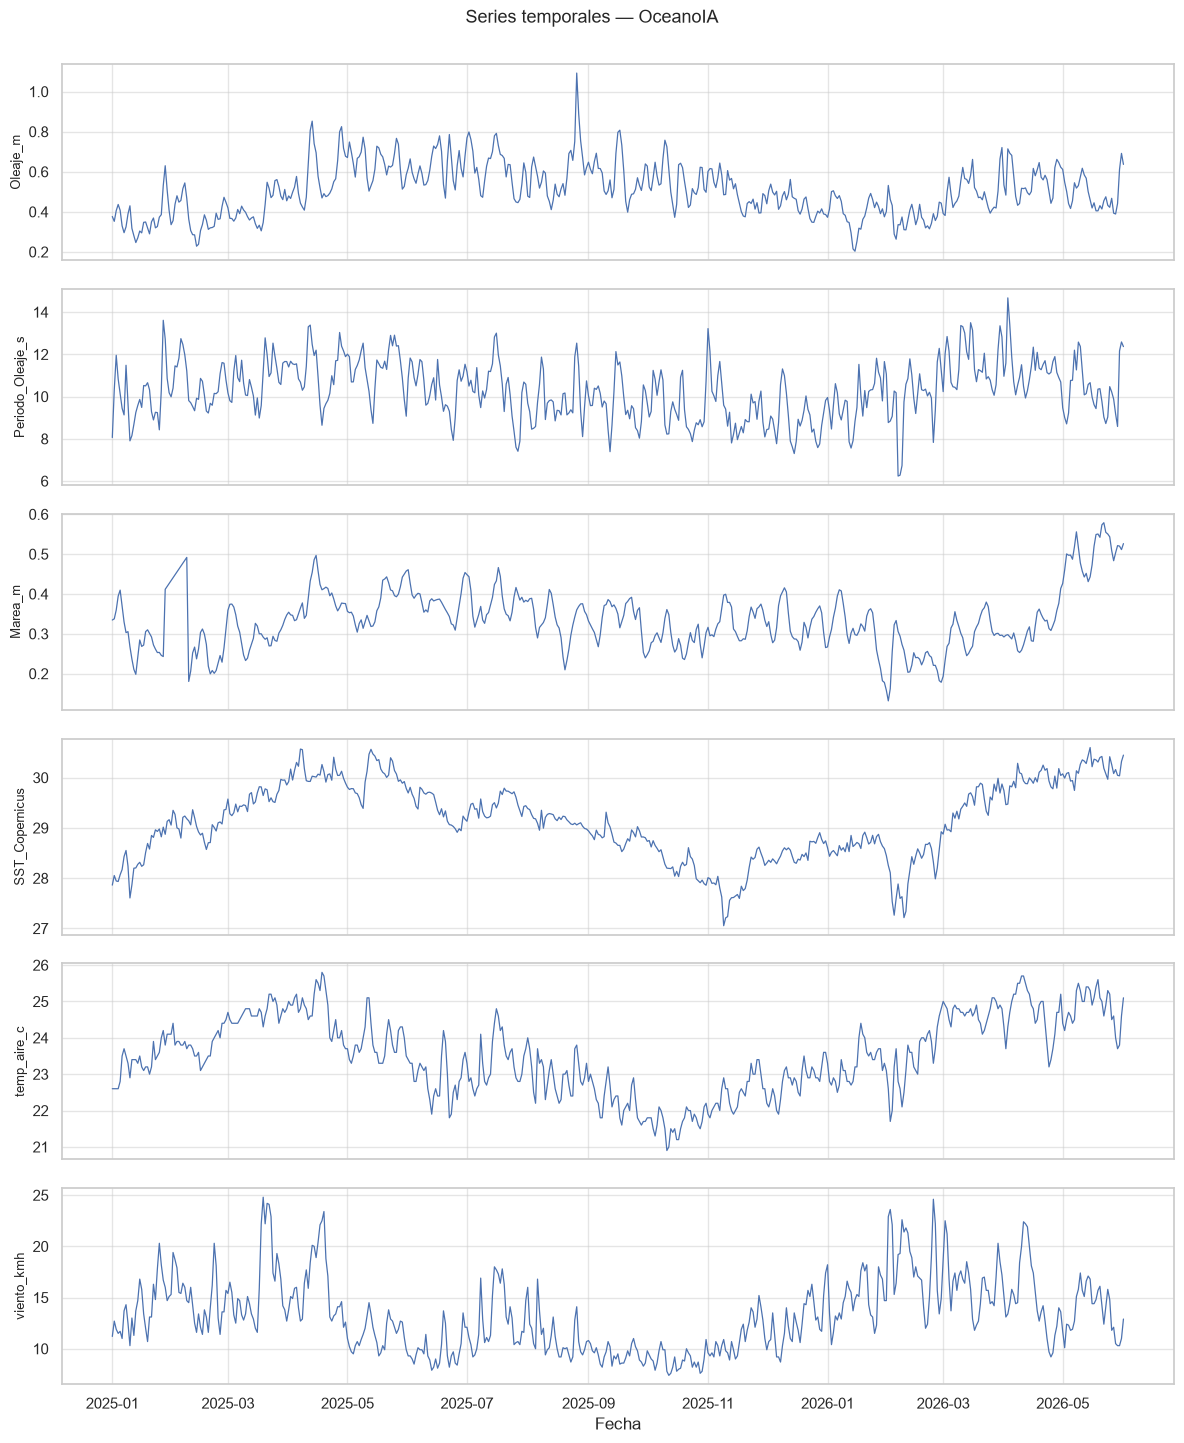

In [5]:
variables = [
    'Oleaje_m',
    'Periodo_Oleaje_s',
    'Marea_m',
    'SST_Copernicus',
    'temp_aire_c',
    'viento_kmh'
]
n = len(variables)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.4 * n), sharex=True)

axes = axes.flatten()

for ax, col in zip(axes, variables):
    # CORRECCIÓN: Cambiar df por df_consolidado (o el nombre que tenga arriba)
    ax.plot(df.index, df[col], linewidth=0.9)
    ax.set_ylabel(col, fontsize=9)
axes[-1].set_xlabel('Fecha')
fig.suptitle('Series temporales — OceanoIA', y=1.001, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Distribuciones (histogramas)
### ¿Qué nos dicen?
Al mirar estos gráficos de barras, podemos ver cómo se reparten los valores de cada variable. La mayoría de ellas, como el oleaje, las temperaturas y la marea, tienen una forma de "campana", lo que significa que la gran parte de los datos se concentra de manera natural alrededor de un valor promedio y no hay valores extraños o errores aislados que ensucien el dataset. Otras variables, como la humedad o las nubes, muestran un comportamiento más variado pero totalmente normal para el clima de la zona. En resumen, estos gráficos nos confirman que los datos tienen un comportamiento estable, sano y bien distribuido, ideal para que la red neuronal pueda aprender sin problemas.

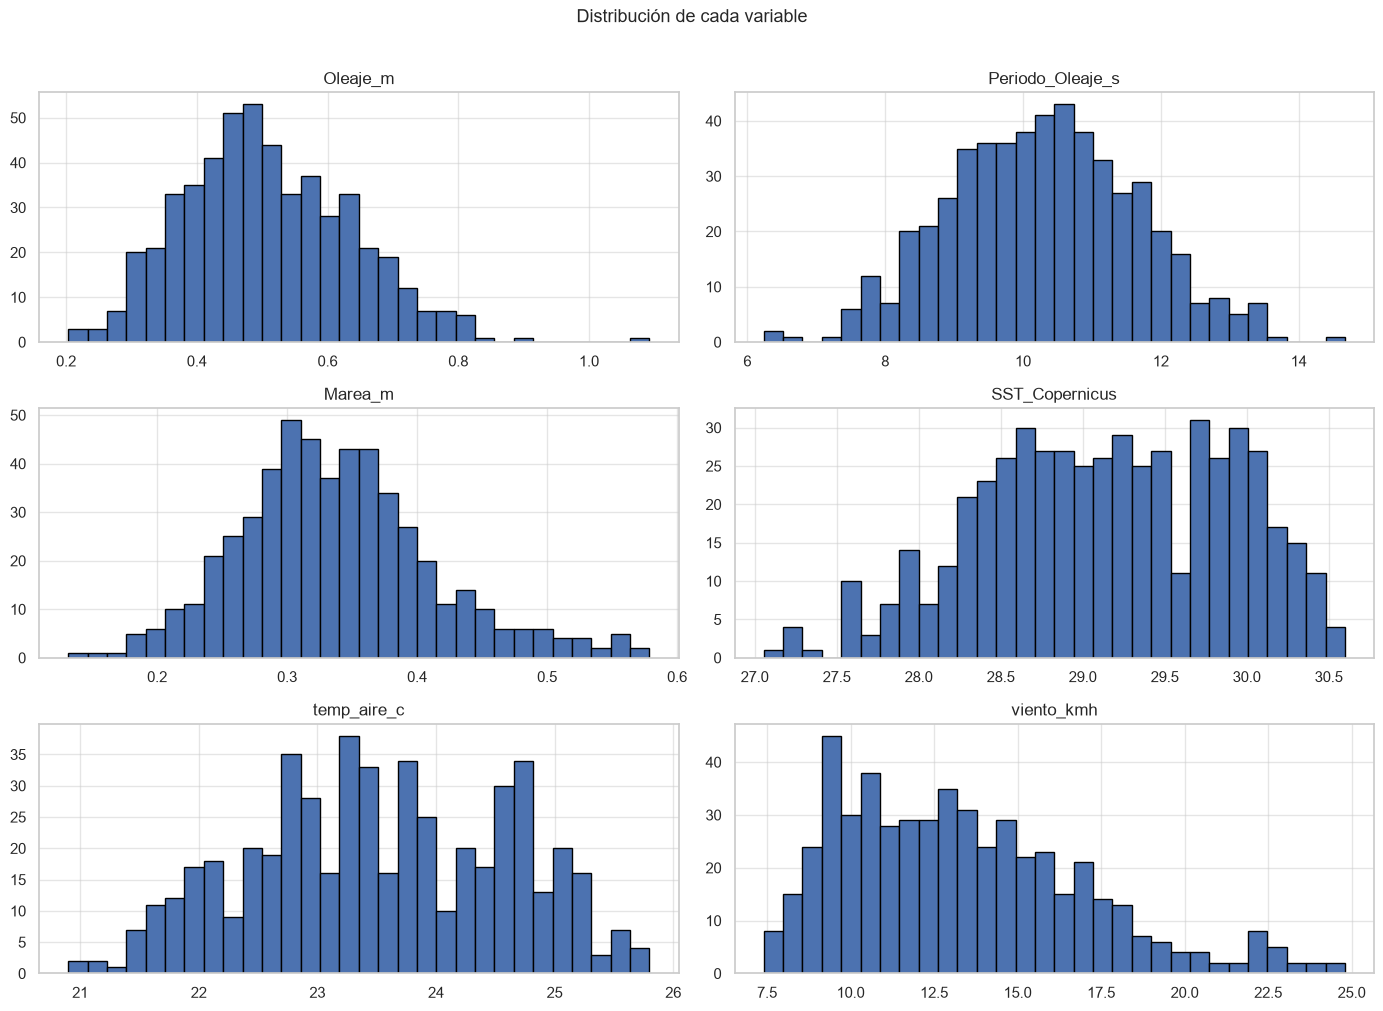

In [6]:
df[variables].hist(bins=30, figsize=(14, 10), edgecolor='black')
plt.suptitle('Distribución de cada variable', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Detección de valores atípicos (boxplots)
Al escalar todas las variables juntas, podemos comparar directamente cómo varía cada una. Las cajas más largas, como las de humedad y nubes, nos indican que estos datos cambian de forma más extrema y abarcan rangos muy amplios. Por otro lado, los puntos sueltos en los extremos representan los "valores atípicos" o momentos especiales del año: por ejemplo, las ráfagas de viento más fuertes de lo común, las mareas más altas de lo normal y un par de horas específicas donde la dirección del oleaje cambió por completo. El resto de las variables se mantienen muy estables dentro de sus límites normales, confirmando que el dataset tiene un comportamiento real, limpio y balanceado para el modelado.

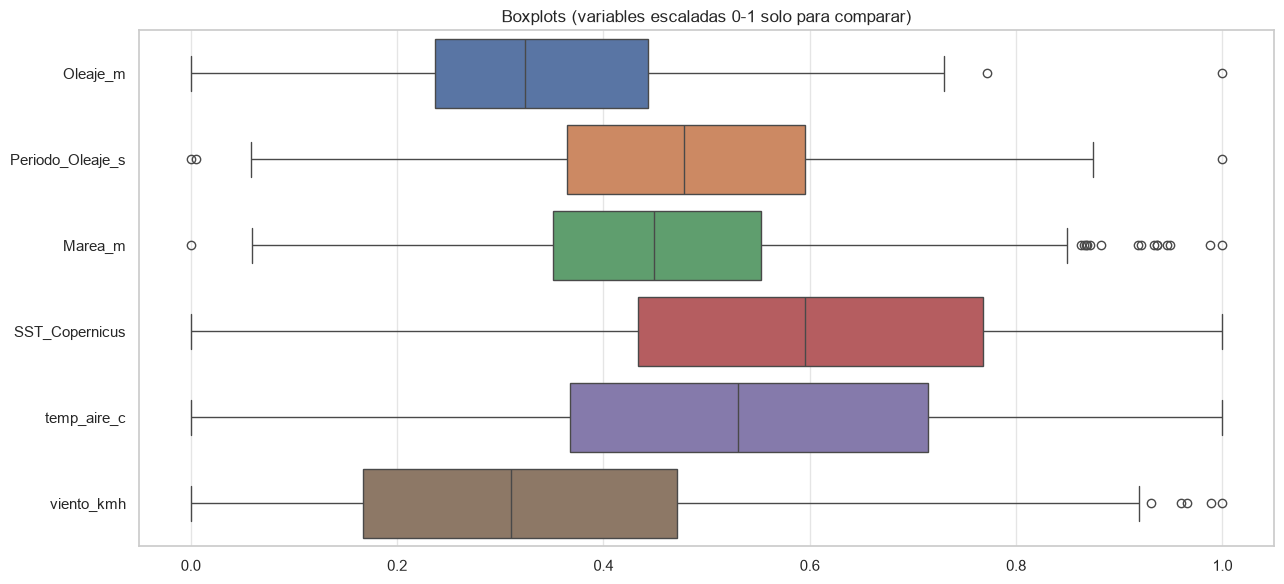

In [7]:
from sklearn.preprocessing import MinMaxScaler
esc = pd.DataFrame(MinMaxScaler().fit_transform(df[variables]),
                   columns=variables, index=df.index)
plt.figure(figsize=(13, 6))
sns.boxplot(data=esc, orient='h')
plt.title('Boxplots (variables escaladas 0-1 solo para comparar)')
plt.tight_layout()
plt.show()

## 7. Correlaciones entre variables
Este gráfico nos muestra cómo se relacionan las variables entre sí. Los tonos rojos representan una relación directa (si una variable sube, la otra también), lo que se nota claramente entre todas las temperaturas del aire y la del mar (`SST_Copernicus`). Los tonos azules indican una relación inversa (si una sube, la otra baja), destacando que cuando el viento (`viento_kmh`) y la temperatura aumentan, la humedad (`humedad_pct`) disminuye drásticamente (-0.85). Por último, descubrimos que el oleaje (`Oleaje_m`) está muy amarrado a los días de alta nubosidad y humedad, lo que refleja el impacto del mal tiempo en el estado del mar. Estos lazos le dan pistas valiosas a la red neuronal para entender qué buscar a la hora de hacer predicciones.

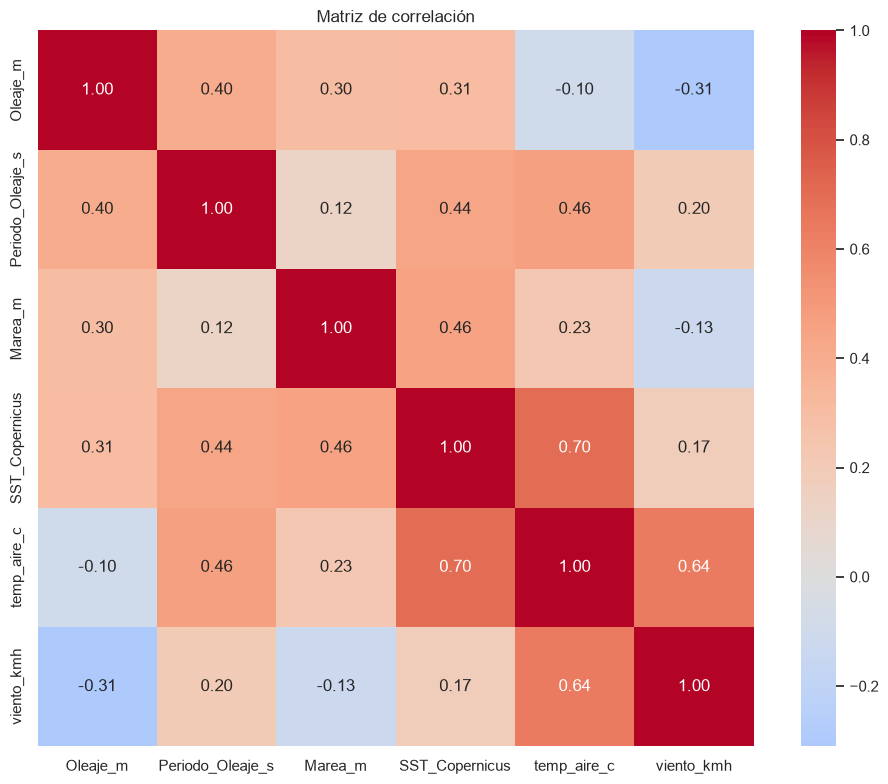

In [8]:
corr = df[variables].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## 8. Patrón mensual (estacionalidad)
Promediamos por mes para ver el ciclo estacional de las variables clave

### ¿Qué nos muestra el Promedio Mensual?
Este análisis agrupa los datos mes a mes para entender cómo se comporta el clima costero a lo largo de las estaciones del año. Destaca que los meses de mayo, junio y julio registran el oleaje (`Oleaje_m`) promedio más alto del año, coincidiendo con la época de mayor oleaje estacional en el Pacífico. Por el contrario, la velocidad del viento (`viento_kmh`) tiene sus picos más fuertes a inicio de año (febrero y marzo) y cae a sus niveles mínimos en septiembre y octubre. Finalmente, la temperatura del mar (`SST_Copernicus`) y la presión atmosférica (`presion_hpa`) demuestran ser variables sumamente estables que mantienen valores cálidos y constantes durante los doce meses.

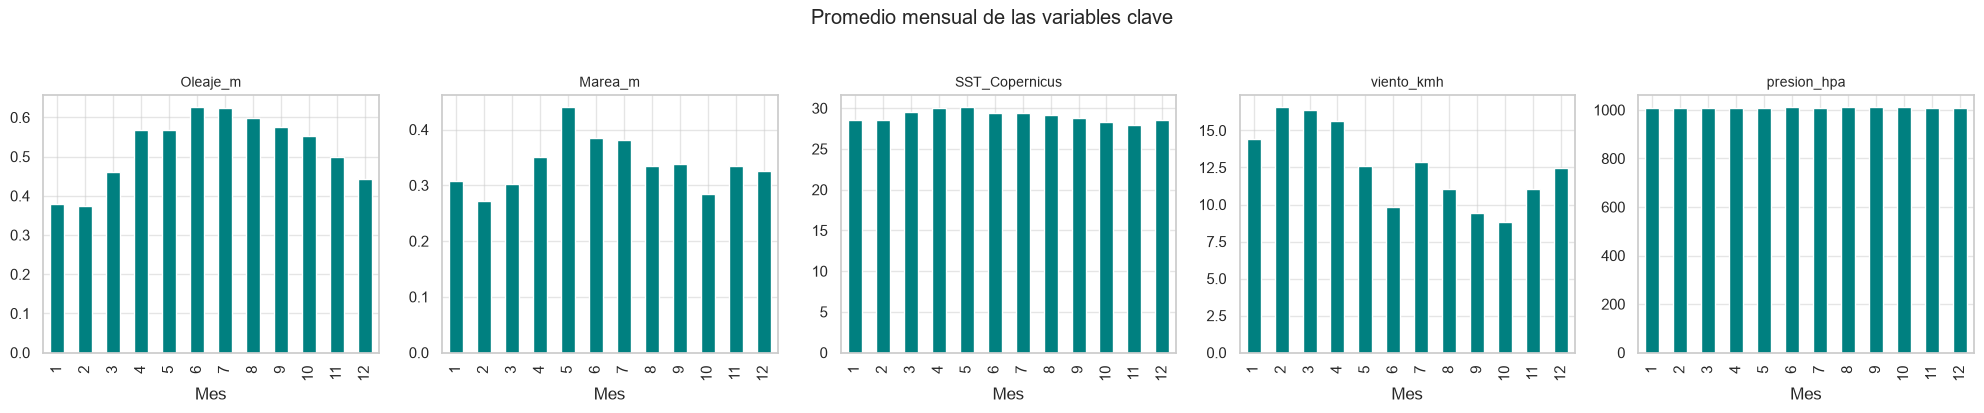

In [9]:
clave = [c for c in ['Oleaje_m','Marea_m','SST_Copernicus','viento_kmh','presion_hpa'] if c in df.columns]
mensual = df[clave].groupby(df.index.month).mean()
mensual.index.name = 'Mes'
fig, axes = plt.subplots(1, len(clave), figsize=(4*len(clave), 4))
for ax, col in zip(np.atleast_1d(axes), clave):
    mensual[col].plot(kind='bar', ax=ax, color='teal')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Mes')
plt.suptitle('Promedio mensual de las variables clave', y=1.03)
plt.tight_layout()
plt.show()
